### Sequential workflow

Here we will be creating the sequential graph using langgraph

In [2]:
!pip install langgraph

In [8]:
from langchain_openai import ChatOpenAI
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
from typing import TypedDict

In [7]:
load_dotenv()

True

### Prompt Chaining

We will be creating the sequential graph using prompt chaining workflow. 

1) In this we will be giving the topic to the LLM -> 2) We will ask llm to generate the outlines -> 3) we will ask llm to generate the detailed blog using the outlines about the topic -> 4) we will ask llm to give the summary of the topic

In [45]:
# Type dict consisting of topic, outlines, blog, summary

class BlogState(TypedDict):
    topic: str
    outlines: str
    blog: str
    summary: str

In [46]:
def create_outline(state: BlogState) -> BlogState:
    topic = state['topic']

    state['outlines'] = model.invoke(f"Create the outlines for topic {topic}").content

    return state

In [47]:
def create_blog(state: BlogState) -> BlogState:
    topic = state['topic']
    outline = state['outlines']

    state['blog'] = model.invoke(f"Create the blog for topic {topic} and considering the outlines {outline}").content

    return state

In [48]:
def create_summary(state: BlogState) -> BlogState:
    topic = state['topic']
    outline = state['outlines']
    blog = state['blog']

    state['summary'] = model.invoke(f"Give me the summary of blog {blog} which is on topic {topic} having outlines: {outline}").content

    return state

In [49]:
# Creating the graph object using StateGraph
graph = StateGraph(BlogState)

# Creating model object
model = ChatOpenAI(model='gpt-5.4-mini', max_completion_tokens=300)

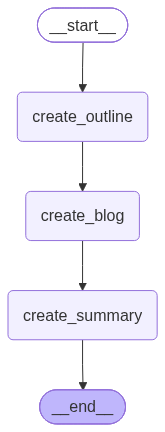

In [50]:
# Adding nodes
graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)
graph.add_node('create_summary', create_summary)

# Adding edges
graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_blog')
graph.add_edge('create_blog', 'create_summary')
graph.add_edge('create_summary', END)

# Compiling graph
workflow = graph.compile()

workflow

In [51]:
initial_state = {'topic': 'AI in Banking'}
res = workflow.invoke(initial_state)

In [52]:
print('topic: ' + res['topic'])
print('\noutlines: ' + res['outlines'])
print('\nblog: ' + res['blog'])
print('\nsummary: ' + res['summary'])

topic: AI in Banking

outlines: Here’s a clear outline for the topic **“AI in Banking”**:

## 1. Introduction
- Definition of Artificial Intelligence
- Overview of banking industry
- Importance of AI in modern banking

## 2. Evolution of AI in Banking
- Early automation in banks
- Shift from rule-based systems to intelligent systems
- Current state of AI adoption in banking

## 3. Key Applications of AI in Banking
### a. Customer Service
- Chatbots and virtual assistants
- 24/7 support
- Personalized customer interactions

### b. Fraud Detection and Prevention
- Transaction monitoring
- Anomaly detection
- Real-time alerts

### c. Risk Management
- Credit scoring
- Loan approval decisions
- Predictive analytics for market and operational risks

### d. Process Automation
- Automating repetitive back-office tasks
- Document processing
- Compliance reporting

### e. Personalized Banking Services
- Product recommendations
- Spending analysis
- Financial planning tools

### f. Trading and I